<a href="https://colab.research.google.com/github/Tortugo2605/Mec-nica-de-materiales-/blob/main/Analisis_Flexion_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DE ESFUERZO NORMAL EN ELEMENTOS SOMETIDOS A FLEXIÓN
Descripción del Algoritmo:
Este programa calcula el esfuerzo normal total provocado por cargas
de flexión (Mx, My) y axiales (N) en tres tipos distintos de
secciones transversales elongadas: Perfil en L, Perfil en I y
Perfil en O hueco (tubular).
El usuario debe ingresar la geometría y el programa determinará
las propiedades centroidales, inercia y los esfuerzos en puntos
clave, mostrando la salida tanto en terminal como en entorno gráfico.

SELECCIONE EL CASO A ANALIZAR:
1. Caso 'a' - Perfil en L
2. Caso 'b' - Perfil en I
3. Caso 'c' - Perfil en O (Tubular hueco)
4. Salir

Ingrese el número de la opción deseada (1-4): 1

--- INGRESO DE DATOS DE LA GEOMETRÍA (EN METROS) ---
Ingrese la base (ancho del ala horizontal): 5
Ingrese la altura (ala vertical): 10
Ingrese el espesor de la sección: 3

RESULTADOS DE ESFUERZOS EN PUNTOS DE ANÁLISIS:
Pto          | x (m)      | y (m)      | σ_N (Pa)   | σ_Mx (Pa)  | σ_My (Pa)  | σ_T (Pa) 

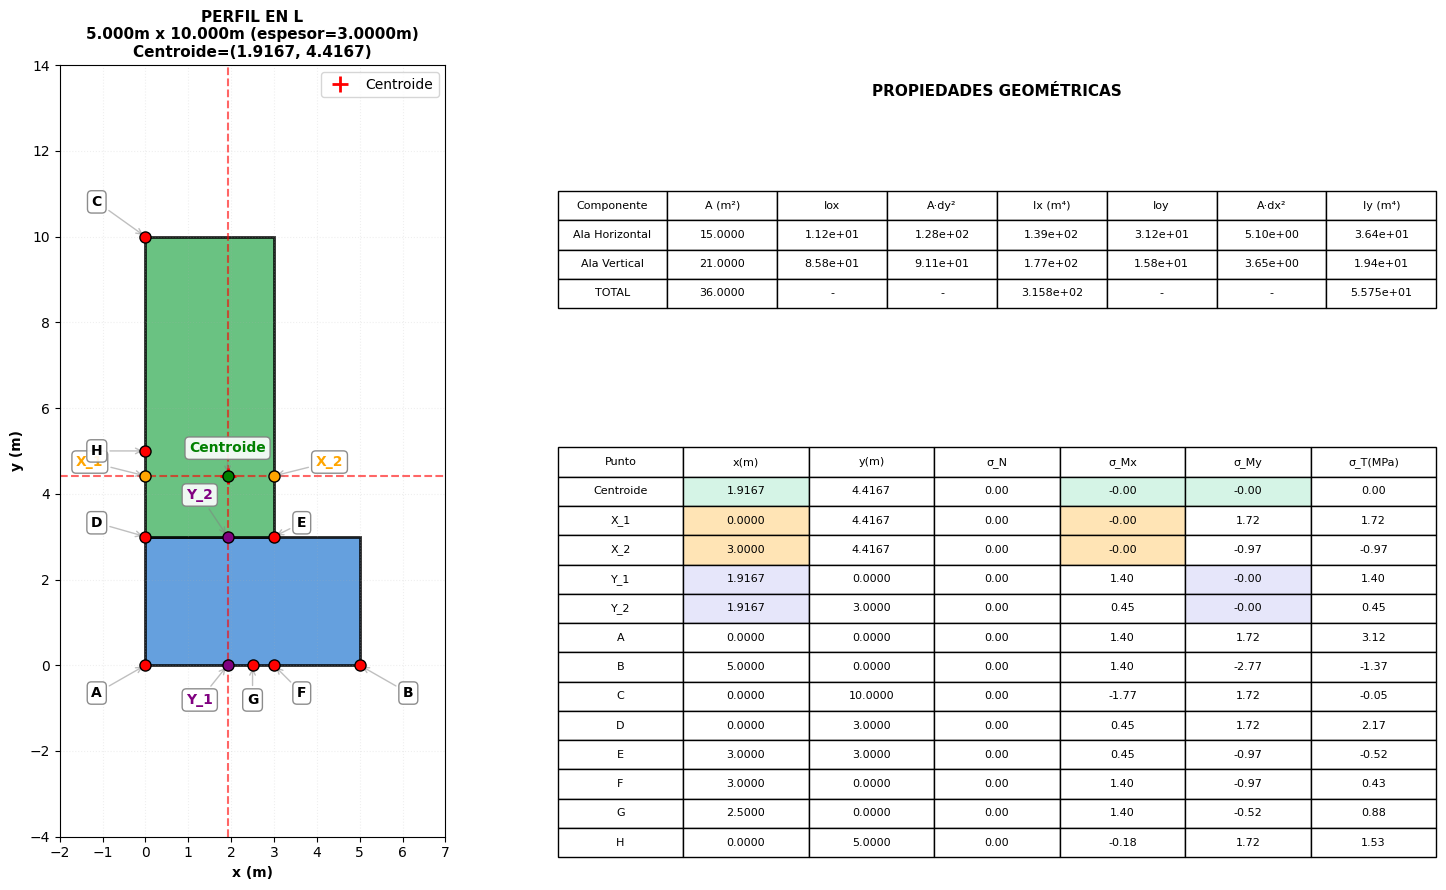


SELECCIONE EL CASO A ANALIZAR:
1. Caso 'a' - Perfil en L
2. Caso 'b' - Perfil en I
3. Caso 'c' - Perfil en O (Tubular hueco)
4. Salir


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

def imprimir_consola(resultados):
    print("\nRESULTADOS DE ESFUERZOS EN PUNTOS DE ANÁLISIS:")
    print(f"{'Pto':<12} | {'x (m)':<10} | {'y (m)':<10} | {'σ_N (Pa)':<10} | {'σ_Mx (Pa)':<10} | {'σ_My (Pa)':<10} | {'σ_T (Pa)':<12}")
    print("-" * 88)
    for r in resultados:
        print(f"{r[0]:<12} | {r[1]:<10} | {r[2]:<10} | {r[3]:<10} | {r[4]:<10} | {r[5]:<10} | {r[6]:<12}")
    print("-" * 88)

# ==========================================
# FUNCIONES - PERFIL I
# ==========================================

def calcular_perfil_I(Ancho, Alto, Espesor):
    bf = Ancho
    tf = Espesor
    tw = Espesor
    hw = Alto - 2*Espesor

    if hw <= 0:
        raise ValueError(f"Error: El espesor {Espesor} es muy grande para el alto {Alto}")

    h = hw + 2*tf
    yc = h/2
    xc = bf/2

    figs = [
        ['Patín Inf', bf, tf, bf*tf, tf/2, bf/2],
        ['Alma', tw, hw, tw*hw, tf + hw/2, bf/2],
        ['Patín Sup', bf, tf, bf*tf, tf + hw + tf/2, bf/2]
    ]

    tabla, Ix, Iy, A = [], 0, 0, 0
    for nom, b, h_f, area, ycg, xcg in figs:
        Iox, Ioy = b*h_f**3/12, h_f*b**3/12
        dy, dx = ycg - yc, xcg - xc
        Ix_f, Iy_f = Iox + area*dy**2, Ioy + area*dx**2
        Ix += Ix_f
        Iy += Iy_f
        A += area
        tabla.append([nom, f"{area:.4f}", f"{Iox:.2e}", f"{area*dy**2:.2e}", f"{Ix_f:.2e}",
                     f"{Ioy:.2e}", f"{area*dx**2:.2e}", f"{Iy_f:.2e}"])
    tabla.append(['TOTAL', f"{A:.4f}", '-', '-', f"{Ix:.3e}", '-', '-', f"{Iy:.3e}"])

    return {'A': A, 'Ix': Ix, 'Iy': Iy, 'h': h, 'b': bf, 'tabla': tabla, 'tf': tf, 'tw': tw, 'hw': hw}

def generar_puntos_perfil_I(bf, h, tf):
    puntos = [
        ('a', -bf/2, h/2), ('b', 0, h/2), ('c', bf/2, h/2),
        ('d', -bf/2, h/2-tf), ('e', -tf/2, h/2-tf), ('f', tf/2, h/2-tf), ('g', bf/2, h/2-tf),
        ('h', -tf/2, 0), ('i', tf/2, 0),
        ('j', -bf/2, -h/2+tf), ('k', -tf/2, -h/2+tf), ('l', tf/2, -h/2+tf), ('m', bf/2, -h/2+tf),
        ('n', -bf/2, -h/2), ('ñ', 0, -h/2), ('o', bf/2, -h/2),
    ]
    return puntos

def graficar_perfil_I(props, Mx, My, N, puntos):
    bf, h, tf = props['b'], props['h'], props['tf']
    fig = plt.figure(figsize=(16, 9))
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 1))

    ax1.add_patch(Rectangle((-bf/2, h/2 - tf), bf, tf, ec='black', fc='#4A90D9', lw=2, alpha=0.85))
    ax1.add_patch(Rectangle((-tf/2, -h/2 + tf), tf, h - 2*tf, ec='black', fc='#50B86C', lw=2, alpha=0.85))
    ax1.add_patch(Rectangle((-bf/2, -h/2), bf, tf, ec='black', fc='#4A90D9', lw=2, alpha=0.85))

    ax1.axhline(0, c='red', ls='--', alpha=0.6, lw=1.5)
    ax1.axvline(0, c='red', ls='--', alpha=0.6, lw=1.5)
    ax1.plot(0, 0, 'r+', markersize=12, markeredgewidth=2, zorder=5)

    margin_x, margin_y = bf * 0.3, h * 0.3
    ax1.set_xlim(-bf/2 - margin_x, bf/2 + margin_x)
    ax1.set_ylim(-h/2 - margin_y, h/2 + margin_y)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.2, linestyle=':')
    ax1.set_xlabel('x (m)', fontsize=10, fontweight='bold')
    ax1.set_ylabel('y (m)', fontsize=10, fontweight='bold')
    ax1.set_title(f'PERFIL I\n{bf:.3f}m x {h:.3f}m (espesor={tf:.4f}m)', fontweight='bold', fontsize=11)

    resultados = []
    desplazamientos = {
        'a': (-35, 20), 'b': (0, 25), 'c': (35, 20), 'd': (-40, 15), 'e': (-20, 18), 'f': (20, 18), 'g': (40, 15),
        'h': (-25, 10), 'i': (25, 10), 'j': (-40, -15), 'k': (-20, -18), 'l': (20, -18), 'm': (40, -15),
        'n': (-35, -20), 'ñ': (0, -25), 'o': (35, -20)
    }

    for nom, x_real, y_real in puntos:
        sN = N / props['A']
        sMx = -Mx * y_real / props['Ix']
        sMy = -My * x_real / props['Iy']
        sT = sN + sMx + sMy
        resultados.append([nom, f"{x_real:.4f}", f"{y_real:.4f}", f"{sN:.2f}", f"{sMx:.2f}", f"{sMy:.2f}", f"{sT:.2f}"])

        color_punto = 'green' if abs(sMx) < 1e-6 and abs(sMy) < 1e-6 else ('orange' if abs(sMx) < 1e-6 else ('purple' if abs(sMy) < 1e-6 else 'red'))
        color_texto = color_punto if color_punto != 'red' else 'black'

        ax1.plot(x_real, y_real, 'o', color=color_punto, markersize=8, zorder=5, markeredgecolor='black', markeredgewidth=1)
        dx, dy = desplazamientos.get(nom, (0, 20))
        ax1.annotate(nom, xy=(x_real, y_real), xytext=(dx, dy), textcoords='offset points', ha='center', va='center',
                    fontsize=13, fontweight='bold', color=color_texto, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'), arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))

    ax2.axis('off')
    table1 = ax2.table(cellText=props['tabla'], colLabels=['Componente', 'A (m²)', 'Iox', 'A·dy²', 'Ix (m⁴)', 'Ioy', 'A·dx²', 'Iy (m⁴)'], loc='center', cellLoc='center')
    table1.auto_set_font_size(False)
    table1.set_fontsize(8)
    table1.scale(1.1, 1.5)
    ax2.text(0.5, 0.95, 'PROPIEDADES GEOMÉTRICAS', transform=ax2.transAxes, ha='center', va='top', fontweight='bold', fontsize=11)

    ax3.axis('off')
    table2 = ax3.table(cellText=resultados, colLabels=['Pto', 'x(m)', 'y(m)', 'σ_N', 'σ_Mx', 'σ_My', 'σ_T(MPa)'], loc='center', cellLoc='center')
    table2.auto_set_font_size(False)
    table2.set_fontsize(8)
    table2.scale(1.1, 1.5)

    for i in range(1, len(resultados) + 1):
        row = resultados[i-1]
        sMx_val, sMy_val = abs(float(row[4])) < 1e-6, abs(float(row[5])) < 1e-6
        if sMx_val and sMy_val:
            for col in [1, 4, 5]: table2[(i, col)].set_facecolor('#D5F4E6')
        elif sMx_val:
            for col in [1, 4]: table2[(i, col)].set_facecolor('#FFE4B5')
        elif sMy_val:
            for col in [1, 5]: table2[(i, col)].set_facecolor('#E6E6FA')

    plt.subplots_adjust(hspace=0.02, wspace=0.3)
    plt.tight_layout()
    imprimir_consola(resultados)
    plt.show()

# ==========================================
# FUNCIONES - PERFIL L
# ==========================================

def calcular_perfil_L(Ala1, Ala2, Espesor):
    b, d, t = Ala1, Ala2, Espesor
    A1, A2 = b * t, (d - t) * t
    A_total = A1 + A2
    x1, y1 = b/2, t/2
    x2, y2 = t/2, t + (d - t)/2
    xc, yc = (A1*x1 + A2*x2) / A_total, (A1*y1 + A2*y2) / A_total

    Ix1_local, Iy1_local = b * t**3 / 12, t * b**3 / 12
    dx1, dy1 = x1 - xc, y1 - yc
    Ix1, Iy1 = Ix1_local + A1 * dy1**2, Iy1_local + A1 * dx1**2

    Ix2_local, Iy2_local = t * (d-t)**3 / 12, (d-t) * t**3 / 12
    dx2, dy2 = x2 - xc, y2 - yc
    Ix2, Iy2 = Ix2_local + A2 * dy2**2, Iy2_local + A2 * dx2**2

    Ix_total, Iy_total = Ix1 + Ix2, Iy1 + Iy2
    tabla = [
        ['Ala Horizontal', f"{A1:.4f}", f"{Ix1_local:.2e}", f"{A1*dy1**2:.2e}", f"{Ix1:.2e}", f"{Iy1_local:.2e}", f"{A1*dx1**2:.2e}", f"{Iy1:.2e}"],
        ['Ala Vertical', f"{A2:.4f}", f"{Ix2_local:.2e}", f"{A2*dy2**2:.2e}", f"{Ix2:.2e}", f"{Iy2_local:.2e}", f"{A2*dx2**2:.2e}", f"{Iy2:.2e}"],
        ['TOTAL', f"{A_total:.4f}", '-', '-', f"{Ix_total:.3e}", '-', '-', f"{Iy_total:.3e}"]
    ]
    return {'A': A_total, 'Ix': Ix_total, 'Iy': Iy_total, 'b': b, 'd': d, 't': t, 'xc': xc, 'yc': yc, 'tabla': tabla}

def generar_puntos_L(xc, yc, b, d, t):
    puntos = [
        ('Centroide', 0, 0), ('X_1', -xc, 0), ('X_2', t - xc, 0), ('Y_1', 0, -yc), ('Y_2', 0, t - yc),
        ('A', -xc, -yc), ('B', b - xc, -yc), ('C', -xc, d - yc), ('D', -xc, t - yc), ('E', t - xc, t - yc),
        ('F', t - xc, -yc), ('G', (b/2) - xc, -yc), ('H', -xc, (d/2) - yc),
    ]
    return puntos

def graficar_L(props, Mx, My, N, puntos):
    b, d, t, xc, yc = props['b'], props['d'], props['t'], props['xc'], props['yc']
    fig = plt.figure(figsize=(16, 9))
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 1))

    ax1.add_patch(Rectangle((0, 0), b, t, ec='black', fc='#4A90D9', lw=2, alpha=0.85))
    ax1.add_patch(Rectangle((0, t), t, d-t, ec='black', fc='#50B86C', lw=2, alpha=0.85))
    ax1.plot(xc, yc, 'r+', markersize=12, markeredgewidth=2, zorder=5, label='Centroide')
    ax1.axhline(yc, c='red', ls='--', alpha=0.6, lw=1.5)
    ax1.axvline(xc, c='red', ls='--', alpha=0.6, lw=1.5)

    margin_x, margin_y = max(b, t) * 0.4, max(d, t) * 0.4
    ax1.set_xlim(-margin_x, b + margin_x)
    ax1.set_ylim(-margin_y, d + margin_y)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.2, linestyle=':')
    ax1.set_xlabel('x (m)', fontsize=10, fontweight='bold')
    ax1.set_ylabel('y (m)', fontsize=10, fontweight='bold')
    ax1.set_title(f'PERFIL EN L\n{b:.3f}m x {d:.3f}m (espesor={t:.4f}m)\nCentroide=({xc:.4f}, {yc:.4f})', fontweight='bold', fontsize=11)
    ax1.legend(loc='upper right')

    resultados = []
    desplazamientos = {
        'Centroide': (0, 20), 'X_1': (-40, 10), 'X_2': (40, 10), 'Y_1': (-20, -25), 'Y_2': (-20, 30),
        'A': (-35, -20), 'B': (35, -20), 'C': (-35, 25), 'D': (-35, 10), 'E': (20, 10), 'F': (20, -20),
        'G': (0, -25), 'H': (-35, 0)
    }

    for nom, x_rel, y_rel in puntos:
        x_abs, y_abs = x_rel + xc, y_rel + yc
        sN = N / props['A']
        sMx = -Mx * (y_abs - yc) / props['Ix']
        sMy = -My * (x_abs - xc) / props['Iy']
        sT = sN + sMx + sMy
        resultados.append([nom, f"{x_abs:.4f}", f"{y_abs:.4f}", f"{sN:.2f}", f"{sMx:.2f}", f"{sMy:.2f}", f"{sT:.2f}"])

        color_punto = 'green' if abs(sMx) < 1e-6 and abs(sMy) < 1e-6 else ('orange' if abs(sMx) < 1e-6 else ('purple' if abs(sMy) < 1e-6 else 'red'))
        color_texto = color_punto if color_punto != 'red' else 'black'

        ax1.plot(x_abs, y_abs, 'o', color=color_punto, markersize=8, zorder=5, markeredgecolor='black', markeredgewidth=1)
        dx, dy = desplazamientos.get(nom, (0, 20))
        ax1.annotate(nom, xy=(x_abs, y_abs), xytext=(dx, dy), textcoords='offset points', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color_texto, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'), arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))

    ax2.axis('off')
    table1 = ax2.table(cellText=props['tabla'], colLabels=['Componente', 'A (m²)', 'Iox', 'A·dy²', 'Ix (m⁴)', 'Ioy', 'A·dx²', 'Iy (m⁴)'], loc='center', cellLoc='center')
    table1.auto_set_font_size(False)
    table1.set_fontsize(8)
    table1.scale(1.1, 1.5)
    ax2.text(0.5, 0.95, 'PROPIEDADES GEOMÉTRICAS', transform=ax2.transAxes, ha='center', va='top', fontweight='bold', fontsize=11)

    ax3.axis('off')
    table2 = ax3.table(cellText=resultados, colLabels=['Punto', 'x(m)', 'y(m)', 'σ_N', 'σ_Mx', 'σ_My', 'σ_T(MPa)'], loc='center', cellLoc='center')
    table2.auto_set_font_size(False)
    table2.set_fontsize(8)
    table2.scale(1.1, 1.5)

    for i in range(1, len(resultados) + 1):
        row = resultados[i-1]
        sMx_val, sMy_val = abs(float(row[4])) < 1e-6, abs(float(row[5])) < 1e-6
        if sMx_val and sMy_val:
            for col in [1, 4, 5]: table2[(i, col)].set_facecolor('#D5F4E6')
        elif sMx_val:
            for col in [1, 4]: table2[(i, col)].set_facecolor('#FFE4B5')
        elif sMy_val:
            for col in [1, 5]: table2[(i, col)].set_facecolor('#E6E6FA')

    plt.subplots_adjust(hspace=0.02, wspace=0.3)
    plt.tight_layout()
    imprimir_consola(resultados)
    plt.show()

# ==========================================
# FUNCIONES - PERFIL O HUECO
# ==========================================

def calcular_perfil_O(r_int, t):
    r_ext = r_int + t
    A_ext, A_int = np.pi * r_ext**2, np.pi * r_int**2
    A_total = A_ext - A_int
    xc, yc = 0, 0
    Ix = (np.pi/4) * (r_ext**4 - r_int**4)
    Iy = Ix

    tabla = [
        ['Círculo Exterior', f"{A_ext:.4f}", f"{np.pi*r_ext**4/4:.2e}", '-', f"{np.pi*r_ext**4/4:.2e}", f"{np.pi*r_ext**4/4:.2e}", '-', f"{np.pi*r_ext**4/4:.2e}"],
        ['Círculo Interior', f"{A_int:.4f}", f"{np.pi*r_int**4/4:.2e}", '-', f"{np.pi*r_int**4/4:.2e}", f"{np.pi*r_int**4/4:.2e}", '-', f"{np.pi*r_int**4/4:.2e}"],
        ['TOTAL', f"{A_total:.4f}", '-', '-', f"{Ix:.3e}", '-', '-', f"{Iy:.3e}"]
    ]
    return {'A': A_total, 'Ix': Ix, 'Iy': Iy, 'r_ext': r_ext, 'r_int': r_int, 't': t, 'xc': xc, 'yc': yc, 'tabla': tabla}

def generar_puntos_O(r_ext, r_int, xc, yc):
    puntos = [
        ('Centroide', 0, 0), ('f', r_ext, 0), ('c', -r_ext, 0), ('e', r_int, 0), ('d', -r_int, 0),
        ('a', 0, r_ext), ('h', 0, -r_ext), ('b', 0, r_int), ('g', 0, -r_int),
        ('45_ext', r_ext * np.cos(np.pi/4), r_ext * np.sin(np.pi/4)), ('45_int', r_int * np.cos(np.pi/4), r_int * np.sin(np.pi/4)),
        ('135_ext', r_ext * np.cos(3*np.pi/4), r_ext * np.sin(3*np.pi/4)), ('135_int', r_int * np.cos(3*np.pi/4), r_int * np.sin(3*np.pi/4)),
        ('225_ext', r_ext * np.cos(5*np.pi/4), r_ext * np.sin(5*np.pi/4)), ('225_int', r_int * np.cos(5*np.pi/4), r_int * np.sin(5*np.pi/4)),
        ('315_ext', r_ext * np.cos(7*np.pi/4), r_ext * np.sin(7*np.pi/4)), ('315_int', r_int * np.cos(7*np.pi/4), r_int * np.sin(7*np.pi/4)),
    ]
    return puntos

def graficar_O(props, Mx, My, N, puntos):
    r_ext, r_int, xc, yc = props['r_ext'], props['r_int'], props['xc'], props['yc']
    fig = plt.figure(figsize=(16, 9))
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 1))

    ax1.add_patch(Circle((0, 0), r_ext, ec='black', fc='#4A90D9', lw=2, alpha=0.85))
    ax1.add_patch(Circle((0, 0), r_int, ec='black', fc='white', lw=2, alpha=1.0))
    ax1.plot(xc, yc, 'r+', markersize=12, markeredgewidth=2, zorder=5, label='Centroide')
    ax1.axhline(yc, c='red', ls='--', alpha=0.6, lw=1.5)
    ax1.axvline(xc, c='red', ls='--', alpha=0.6, lw=1.5)

    margin = r_ext * 0.3
    ax1.set_xlim(-r_ext - margin, r_ext + margin)
    ax1.set_ylim(-r_ext - margin, r_ext + margin)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.2, linestyle=':')
    ax1.set_xlabel('x (m)', fontsize=10, fontweight='bold')
    ax1.set_ylabel('y (m)', fontsize=10, fontweight='bold')
    ax1.set_title(f'PERFIL EN O HUECO\nr_ext={r_ext:.4f}m, r_int={r_int:.4f}m, t={props["t"]:.4f}m\nCentroide=({xc:.4f}, {yc:.4f})', fontweight='bold', fontsize=11)
    ax1.legend(loc='upper right')

    resultados = []
    desplazamientos = {
        'Centroide': (0, 20), 'f': (30, 0), 'c': (-35, 0), 'e': (20, 10), 'd': (-25, 10),
        'a': (0, 30), 'h': (0, -35), 'b': (-15, 25), 'g': (-15, -30),
        '45_ext': (30, 30), '45_int': (20, 20), '135_ext': (-35, 30), '135_int': (-25, 20),
        '225_ext': (-35, -35), '225_int': (-25, -25), '315_ext': (30, -35), '315_int': (20, -25),
    }

    for nom, x_rel, y_rel in puntos:
        x_abs, y_abs = x_rel + xc, y_rel + yc
        sN = N / props['A']
        sMx = -Mx * (y_abs - yc) / props['Ix']
        sMy = -My * (x_abs - xc) / props['Iy']
        sT = sN + sMx + sMy
        resultados.append([nom, f"{x_abs:.4f}", f"{y_abs:.4f}", f"{sN:.2f}", f"{sMx:.2f}", f"{sMy:.2f}", f"{sT:.2f}"])

        color_punto = 'green' if abs(sMx) < 1e-6 and abs(sMy) < 1e-6 else ('orange' if abs(sMx) < 1e-6 else ('purple' if abs(sMy) < 1e-6 else 'red'))
        color_texto = color_punto if color_punto != 'red' else 'black'

        ax1.plot(x_abs, y_abs, 'o', color=color_punto, markersize=8, zorder=5, markeredgecolor='black', markeredgewidth=1)
        dx, dy = desplazamientos.get(nom, (0, 20))
        ax1.annotate(nom, xy=(x_abs, y_abs), xytext=(dx, dy), textcoords='offset points', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color_texto, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'), arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))

    ax2.axis('off')
    table1 = ax2.table(cellText=props['tabla'], colLabels=['Componente', 'A (m²)', 'Iox', 'A·dy²', 'Ix (m⁴)', 'Ioy', 'A·dx²', 'Iy (m⁴)'], loc='center', cellLoc='center')
    table1.auto_set_font_size(False)
    table1.set_fontsize(8)
    table1.scale(1.1, 1.5)
    ax2.text(0.5, 0.95, 'PROPIEDADES GEOMÉTRICAS', transform=ax2.transAxes, ha='center', va='top', fontweight='bold', fontsize=11)

    ax3.axis('off')
    table2 = ax3.table(cellText=resultados, colLabels=['Punto', 'x(m)', 'y(m)', 'σ_N', 'σ_Mx', 'σ_My', 'σ_T(MPa)'], loc='center', cellLoc='center')
    table2.auto_set_font_size(False)
    table2.set_fontsize(7)
    table2.scale(1.1, 1.5)

    for i in range(1, len(resultados) + 1):
        row = resultados[i-1]
        sMx_val, sMy_val = abs(float(row[4])) < 1e-6, abs(float(row[5])) < 1e-6
        if sMx_val and sMy_val:
            for col in [1, 4, 5]: table2[(i, col)].set_facecolor('#D5F4E6')
        elif sMx_val:
            for col in [1, 4]: table2[(i, col)].set_facecolor('#FFE4B5')
        elif sMy_val:
            for col in [1, 5]: table2[(i, col)].set_facecolor('#E6E6FA')

    plt.subplots_adjust(hspace=0.02, wspace=0.3)
    plt.tight_layout()
    imprimir_consola(resultados)
    plt.show()

# ==========================================
# ALGORITMO PRINCIPAL
# ==========================================

def main():
    print("=" * 70)
    print("ANÁLISIS DE ESFUERZO NORMAL EN ELEMENTOS SOMETIDOS A FLEXIÓN")
    print("=" * 70)
    print("Descripción del Algoritmo:")
    print("Este programa calcula el esfuerzo normal total provocado por cargas")
    print("de flexión (Mx, My) y axiales (N) en tres tipos distintos de")
    print("secciones transversales elongadas: Perfil en L, Perfil en I y")
    print("Perfil en O hueco (tubular).")
    print("El usuario debe ingresar la geometría y el programa determinará")
    print("las propiedades centroidales, inercia y los esfuerzos en puntos")
    print("clave, mostrando la salida tanto en terminal como en entorno gráfico.")
    print("=" * 70)

    Mx = 100
    My = 50
    N = 0

    while True:
        print("\nSELECCIONE EL CASO A ANALIZAR:")
        print("1. Caso 'a' - Perfil en L")
        print("2. Caso 'b' - Perfil en I")
        print("3. Caso 'c' - Perfil en O (Tubular hueco)")
        print("4. Salir")

        opcion = input("\nIngrese el número de la opción deseada (1-4): ")

        if opcion == '4':
            break

        if opcion not in ['1', '2', '3']:
            print("Opción no válida. Intente nuevamente.")
            continue

        print("\n--- INGRESO DE DATOS DE LA GEOMETRÍA (EN METROS) ---")
        try:
            if opcion == '1':
                b = float(input("Ingrese la base (ancho del ala horizontal): "))
                d = float(input("Ingrese la altura (ala vertical): "))
                t = float(input("Ingrese el espesor de la sección: "))
                props = calcular_perfil_L(b, d, t)
                puntos = generar_puntos_L(props['xc'], props['yc'], props['b'], props['d'], props['t'])
                graficar_L(props, Mx, My, N, puntos)

            elif opcion == '2':
                ancho = float(input("Ingrese el ancho de los patines: "))
                alto = float(input("Ingrese la altura total del perfil: "))
                espesor = float(input("Ingrese el espesor (patines y alma): "))
                props = calcular_perfil_I(ancho, alto, espesor)
                puntos = generar_puntos_perfil_I(props['b'], props['h'], props['tf'])
                graficar_perfil_I(props, Mx, My, N, puntos)

            elif opcion == '3':
                r_int = float(input("Ingrese el radio interior: "))
                t = float(input("Ingrese el espesor de la pared: "))
                props = calcular_perfil_O(r_int, t)
                puntos = generar_puntos_O(props['r_ext'], props['r_int'], props['xc'], props['yc'])
                graficar_O(props, Mx, My, N, puntos)

        except ValueError as e:
            print(f"Error en el ingreso de datos: {e}. Asegúrese de introducir un número válido.")
        except Exception as e:
            print(f"Error de cálculo o de estructura: {e}")

if __name__ == "__main__":
    main()